In [1]:
import pandas as pd
import re
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../src"))
if project_root not in sys.path:
    sys.path.append(project_root)

from visualization import *

In [2]:
data_loc = r'/Users/novak/Library/CloudStorage/GoogleDrive-hc3429@columbia.edu/Shared drives/Turi_lab/Data/PTSD_project/DLC_and_Moseq/sefl_1s_bout/2025_02_06-09_35_01/stats_df_cond_age.csv'
kpms_data = pd.read_csv(data_loc)


In [3]:
def extract_cohort_and_day(name: str):
    """
    Strictly follows the format-based parsing logic:
    - Format 2: cohort with two-part mouse ID (e.g., 28-5)
    - Format 1: standard mouse ID (e.g., 06)
    """
    match2 = re.match(r"(\w+)_([a-zA-Z]+\d*)_(\d+)-(\d+)DLC", name)  # Format 2
    match1 = re.match(r"(\w+)_([a-zA-Z]+\d*)_(\d+)DLC", name)        # Format 1

    if match2:
        cohort_prefix = match2.group(1)
        day = match2.group(2)
        cohort_number1 = match2.group(3)
        cohort_number2 = match2.group(4)
        cohort_id = f"{cohort_prefix}_{cohort_number1}-{cohort_number2}"
    elif match1:
        cohort_prefix = match1.group(1)
        day = match1.group(2)
        cohort_number = match1.group(3)
        cohort_id = f"{cohort_prefix}_{cohort_number}"
    else:
        cohort_id = "unknown"
        day = "unknown"

    return pd.Series([cohort_id, day])


In [4]:
kpms_data['condition'] = kpms_data['group'].str.split(' ').str[0]
kpms_data['age'] = kpms_data['group'].str.split(' ').str[2]
kpms_data[['cohort_id', 'day']] = kpms_data['name'].apply(extract_cohort_and_day)
kpms_data.drop(columns=['name', 'group'], inplace=True)

In [5]:
kpms_data.head()

,syllable,heading_mean,heading_std,heading_min,heading_max,angular_velocity_mean,angular_velocity_std,angular_velocity_min,angular_velocity_max,velocity_px_s_mean,velocity_px_s_std,velocity_px_s_min,velocity_px_s_max,frequency,duration,condition,age,cohort_id,day
0,0,-1.855623,1.080461,-3.140100,3.130117,0.179777,1.564614,-3.962133,4.417604,61.023097,44.765041,2.411511,350.934006,0.40625,3.630769,control,old,ptsd5_06,recall1
1,1,-2.206138,0.462365,-2.911298,-1.376281,0.006980,0.721779,-2.359913,1.830727,23.044742,13.186910,0.000000,60.166116,0.15625,1.786667,control,old,ptsd5_06,recall1
2,2,-1.041603,0.242288,-1.324353,-0.731865,-1.787462,0.465829,-2.298700,-0.901721,84.840601,52.738781,3.664594,162.029921,0.03125,0.933333,control,old,ptsd5_06,recall1
3,5,-2.316737,0.433328,-2.728502,-1.409966,-0.055897,0.515612,-2.154003,1.439773,22.962039,12.342523,2.581726,56.503563,0.09375,5.466667,control,old,ptsd5_06,recall1
4,7,-2.676036,0.190882,-2.836662,-2.327033,0.132700,1.290470,-1.864662,1.600124,43.069682,25.326186,6.143768,92.397708,0.03125,1.333333,control,old,ptsd5_06,recall1


In [6]:
syllable_map = {
    0: 'scanning 1',
    11: 'scanning 2',
    12: 'scanning 3',
    1: 'freezing 1',
    5: 'freezing 2',
    8: 'freezing 3',
    14: 'freezing 4',
    2: 'exploring 1',
    4: 'exploring 2',
    6: 'exploring 3',
    7: 'exploring 4',
    9: 'exploring 5',
    15: 'exploring 6',
    10: 'locomotion 1',
    16: 'locomotion 2',
    17: 'locomotion 3',
    18: 'locomotion 4',
    3: 'random 1',
    13: 'random 2'
}
kpms_data['syllable_name'] = kpms_data['syllable'].map(syllable_map)


In [7]:
# title bank
# Mean Heading (rad)
# Angular Velocity (rad/s)
# Mean Velocity (px/s)
# Syllable Frequency
# Syllable Duration

# frequency
# duration
# velocity_px_s_mean
# heading_mean
# angular_velocity_mean


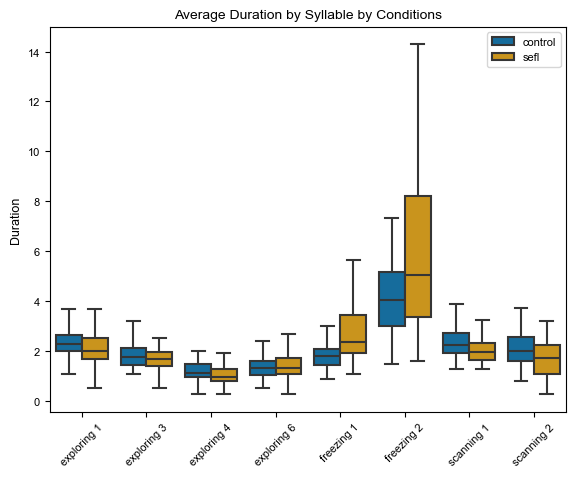

In [8]:
significant_syllables = [2, 6, 7, 15, 1, 5, 0, 11]

create_box_strip_plot(
    kpms_data, 
    'syllable_name', 
    'duration', 
    'condition', 
    'Average Duration by Syllable by Conditions', 
    'Duration', 
    significant_syllables, 
    syllable_map=syllable_map,
    # ylim=(-3.5, 3.5),
    output_filename='/Users/novak/Documents/nyspi/sefl/kpms_svg_figures/figure4a.svg'
)

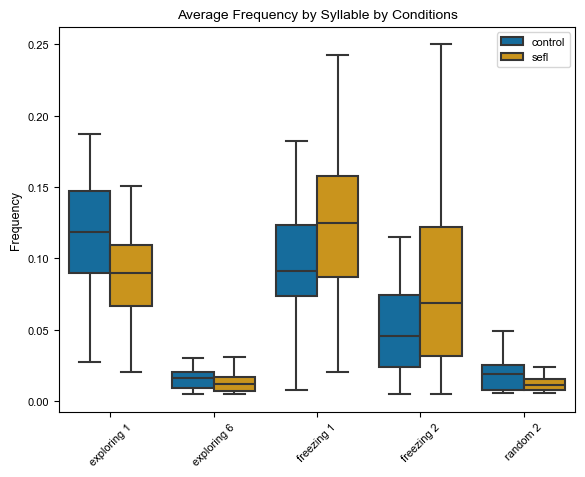

In [9]:
significant_syllables = [ 2, 15, 1, 5, 13]

create_box_strip_plot(
    kpms_data, 
    'syllable_name', 
    'frequency', 
    'condition', 
    'Average Frequency by Syllable by Conditions', 
    'Frequency', 
    significant_syllables, 
    syllable_map=syllable_map,
    # ylim=(-3.5, 3.5),
    output_filename='/Users/novak/Documents/nyspi/sefl/kpms_svg_figures/figure4b.svg'
)

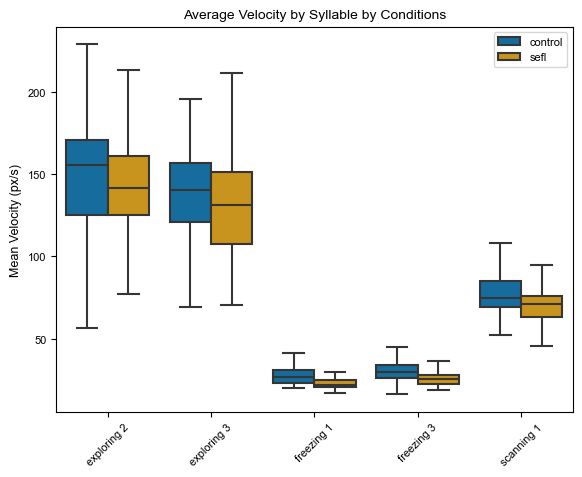

In [10]:
significant_syllables = [4, 6, 1, 8, 0]

create_box_strip_plot(
    kpms_data, 
    'syllable_name', 
    'velocity_px_s_mean', 
    'condition', 
    'Average Velocity by Syllable by Conditions', 
    'Mean Velocity (px/s)', 
    significant_syllables, 
    syllable_map=syllable_map,
    # ylim=(-3.5, 3.5),
    output_filename='/Users/novak/Documents/nyspi/sefl/kpms_svg_figures/figure4c.svg'
)

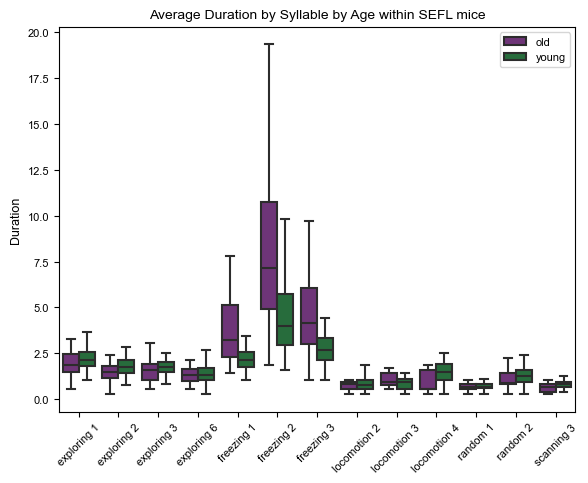

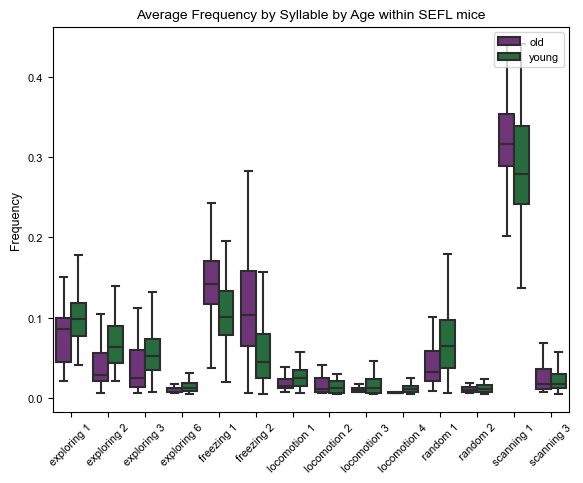

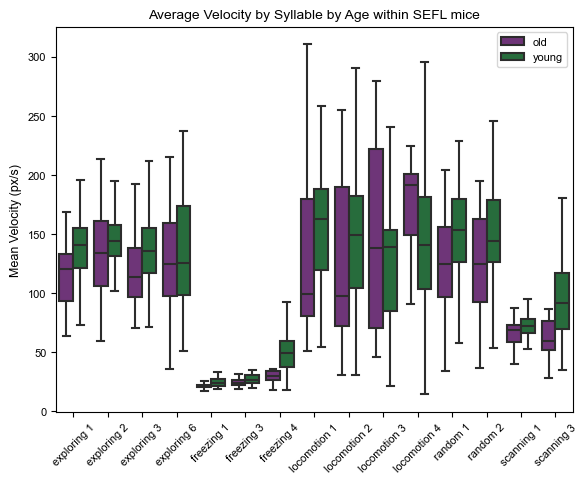

In [11]:
kpms_sefl = kpms_data[kpms_data['condition'] == 'sefl']

significant_duration_syllables = [5, 8, 1, 2, 4, 6, 18, 15, 13, 17, 16, 12, 3]
significant_frequency_syllables = [0, 1, 2, 3, 4, 5, 6, 10, 12, 13, 15, 16, 17, 18]
significant_velocity_syllables = [18, 10, 16, 13, 4, 3, 17, 15, 6, 2, 12, 0, 14, 8, 1]

create_box_strip_plot(
    kpms_sefl, 
    'syllable_name', 
    'duration', 
    'age', 
    'Average Duration by Syllable by Age within SEFL mice', 
    'Duration', 
    significant_duration_syllables, 
    syllable_map=syllable_map,

    output_filename=r'/Users/novak/Documents/nyspi/sefl/kpms_svg_figures/figure5a.svg',
    palette='palette2'
)

create_box_strip_plot(
    kpms_sefl, 
    'syllable_name', 
    'frequency', 
    'age', 
    'Average Frequency by Syllable by Age within SEFL mice', 
    'Frequency', 
    significant_frequency_syllables, 
    syllable_map=syllable_map,

    output_filename=r'/Users/novak/Documents/nyspi/sefl/kpms_svg_figures/figure5b.svg',
    palette='palette2'
)

create_box_strip_plot(
    kpms_sefl, 
    'syllable_name', 
    'velocity_px_s_mean', 
    'age', 
    'Average Velocity by Syllable by Age within SEFL mice', 
    'Mean Velocity (px/s)', 
    significant_velocity_syllables, 
    syllable_map=syllable_map,

    output_filename=r'/Users/novak/Documents/nyspi/sefl/kpms_svg_figures/figure5c.svg',
    palette='palette2'
)

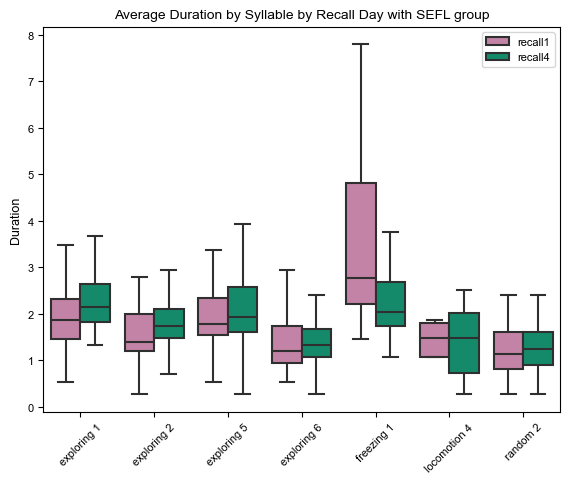

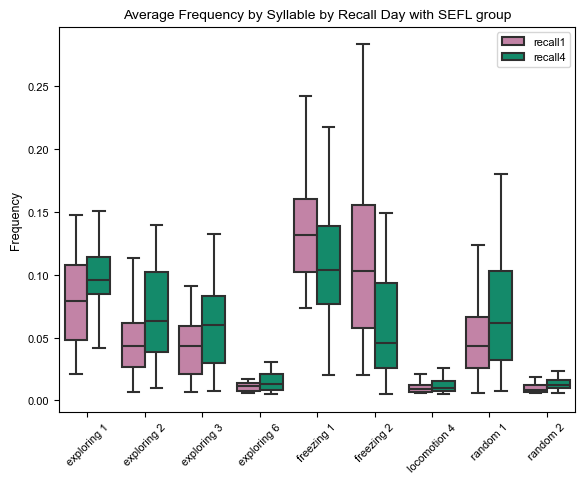

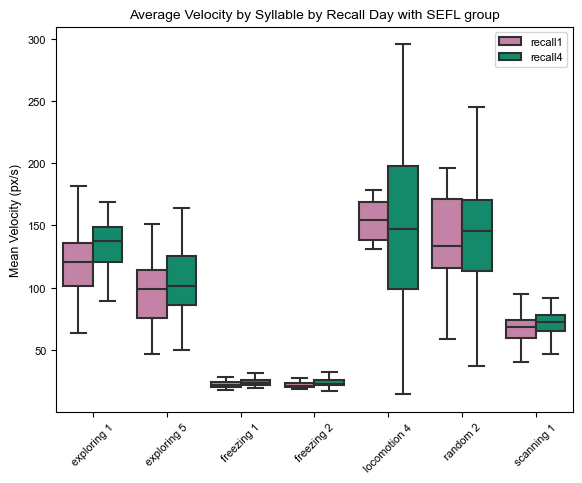

In [12]:
kpms_sefl = kpms_data[kpms_data['condition'] == 'sefl']

significant_duration_syllables = [1, 2, 4, 9, 13, 15, 18]
significant_frequency_syllables = [1, 2, 3, 4, 5, 6, 13, 15, 18]
significant_velocity_syllables = [0, 1, 2, 5, 9, 13, 18]

create_box_strip_plot(
    kpms_sefl, 
    'syllable_name', 
    'duration', 
    'day', 
    'Average Duration by Syllable by Recall Day with SEFL group', 
    'Duration', 
    significant_duration_syllables, 
    syllable_map=syllable_map,

    output_filename=r'/Users/novak/Documents/nyspi/sefl/kpms_svg_figures/figure5d.svg',
    palette='palette4'
)

create_box_strip_plot(
    kpms_sefl, 
    'syllable_name', 
    'frequency', 
    'day', 
    'Average Frequency by Syllable by Recall Day with SEFL group', 
    'Frequency', 
    significant_frequency_syllables, 
    syllable_map=syllable_map,

    output_filename=r'/Users/novak/Documents/nyspi/sefl/kpms_svg_figures/figure5e.svg',
    palette='palette4'
)

create_box_strip_plot(
    kpms_sefl, 
    'syllable_name', 
    'velocity_px_s_mean', 
    'day', 
    'Average Velocity by Syllable by Recall Day with SEFL group', 
    'Mean Velocity (px/s)', 
    significant_velocity_syllables, 
    syllable_map=syllable_map,

    output_filename=r'/Users/novak/Documents/nyspi/sefl/kpms_svg_figures/figure5f.svg',
    palette='palette4'
)